[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GSTT-CSC/summer-school-tutorials/blob/main/day2_qms_regs/QMS_testing_and_validation.ipynb)

# CSC Summer School Day 2 — Testing & Validation

This is the **second half** of the HandOsteo QMS tutorial. In
[`QMS_requirements_and_design.ipynb`](QMS_requirements_and_design.ipynb) you wrote the
requirements, hazard log, and design specification. Here you put them to work:

- **Verification** — *did we build the software right?* Write unit tests that check the
  code against the **System Design Specification (SDS)**.
- **Validation** — *did we build the right software?* Write manual test cases that check
  the system against the clinical need.

You don't need to have finished the first notebook — this one **loads a complete worked
QMS automatically**, so you can focus entirely on testing.

### What HandOsteo does (recap)

It takes an AP hand X-ray (DICOM), validates the modality, classifies the view, measures
the second metacarpal, and returns a report. The stub in `src/handosteo.py` reproduces
that interface without a trained model — and it ships with **two deliberate bugs** for
you to catch.

In [1]:
# Make sure we have all our dependencies installed in Colab
%pip install -q rdm pandas pytest pyyaml pydicom ipytest pillow dicom2nifti nibabel svgwrite ipython

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import shutil
from pathlib import Path

# Clone data + helpers if running on a fresh Colab runtime
if not os.path.isdir("day2_data") or not os.path.exists("src/notebook_helpers.py"):
    !git clone --depth=1 -b main https://github.com/GSTT-CSC/summer-school-tutorials.git _repo
    !cp -rn _repo/day2_qms_regs/day2_data .
    !cp -rn _repo/day2_qms_regs/src .
    !rm -rf _repo

if "." not in sys.path:
    sys.path.insert(0, ".")

# This notebook is about TESTING — load the complete worked QMS so the requirements and
# design specs are the real HandOsteo ones (not the Eratosthenes placeholders).
for src_file in Path("day2_data/data_solutions").iterdir():
    shutil.copy(src_file, f"day2_data/data/{src_file.name}")
print("Worked HandOsteo QMS data loaded into day2_data/data/")

import ipytest
ipytest.autoconfig()

# The boring boilerplate (YAML printing, DICOM plotting, the stub-behaviour table)
# lives in src/notebook_helpers.py so the cells below stay focused on testing.
from src.notebook_helpers import (
    show_yaml,
    show_design_specs,
    plot_dicom_inputs,
    stub_behaviour_table,
)

Worked HandOsteo QMS data loaded into day2_data/data/


# 5. Verification

Verification asks: **have we built the software according to the design specification?**

This notebook zeroes in on the two design specs that govern HandOsteo's input safety:

| SDS | Title | Design intent |
|---|---|---|
| **SDS-001** | DICOM input validation | Only accept DICOMs whose `Modality` is `CR` or `DX`. |
| **SDS-002** | Image view classifier | Only process `AP`/`PA` views; reject oblique views. |

The cell below prints these design specs straight from the loaded QMS data — these are
the statements your unit tests must verify.

In [3]:
# Show the design specs this notebook tests against (SDS-001 and SDS-002).
show_design_specs("day2_data/data/requirements.yml", ids=("SDS-001", "SDS-002"))

sys_des_spec:
  - id: SDS-001
    title: DICOM input validation
    linked_reqs: SRS-001
    description: Validate that each input object is a DICOM hand X-ray and that the
      DICOM Modality tag is CR or DX before processing.
  - id: SDS-002
    title: Image view classifier
    linked_reqs: SRS-002, SRS-007
    description: Classify hand X-ray views as AP, PA, oblique, or unsupported, and
      continue MCP processing only for AP or PA images.



### See how the stub behaves today

We provide stub classes in `src/handosteo.py` that mimic the real pipeline. They are
intentionally imperfect: the loader currently **accepts the wrong modality**, and the
view classifier currently **accepts oblique views** — both should be rejected.

We have 7 synthetic hand X-rays in `day2_data/xray/dicom/`:

| File(s) | Modality | View | Should be |
|---|---|---|---|
| `AP_1`, `AP_2`, `AP_3` | CR | AP | ✅ accepted |
| `Ob_1`, `Ob_2` | CR | OBL (oblique) | ❌ rejected (SDS-002) |
| `CT_1` | CT | AP | ❌ rejected (SDS-001) |
| `MR_1` | MR | AP | ❌ rejected (SDS-001) |

Run the next cells to see the inputs, then watch the stub wrongly accept the obliques and
the CT/MR images.

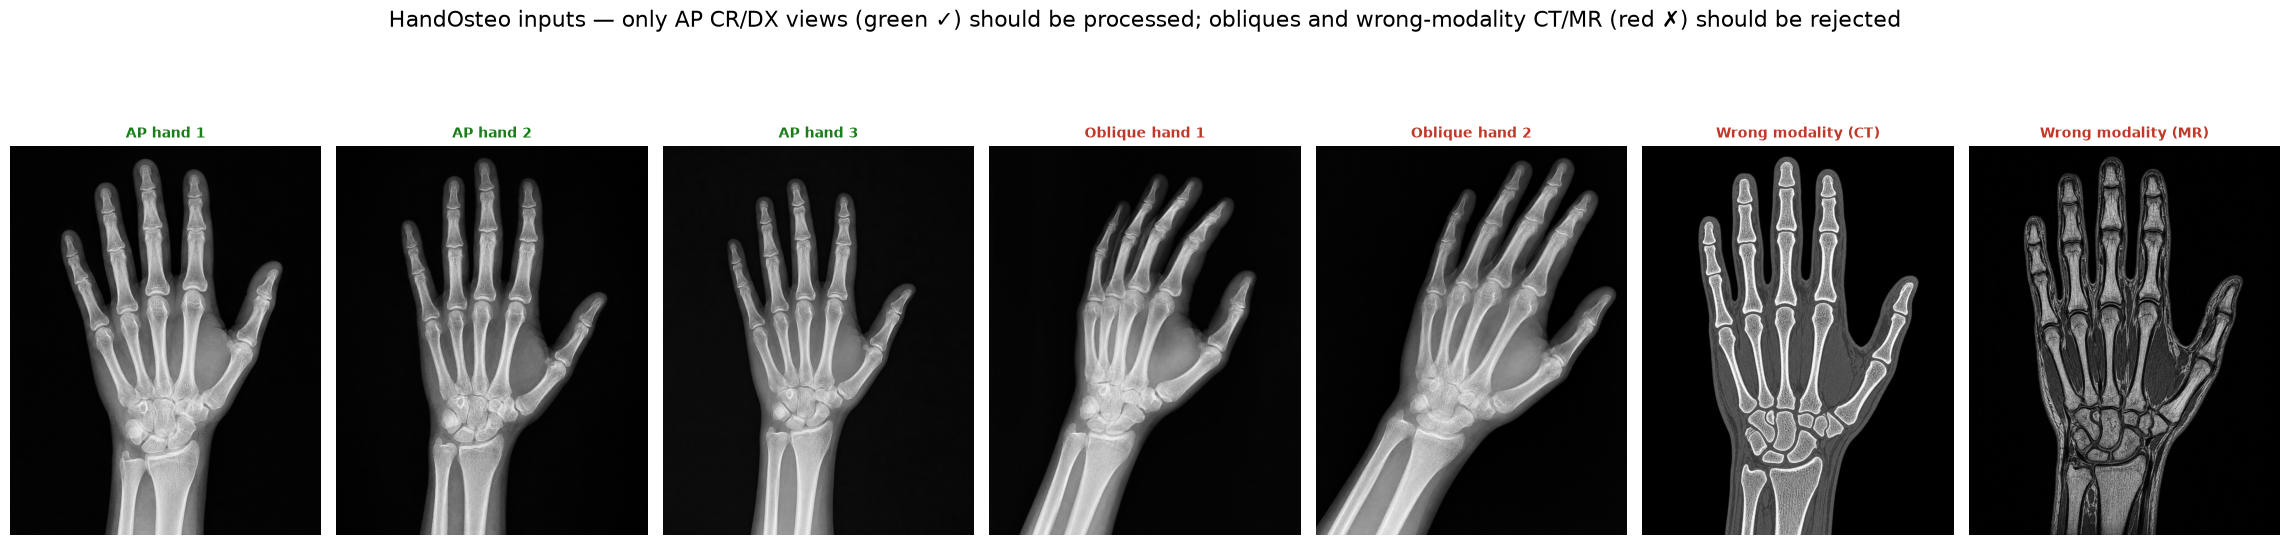

In [4]:
# Plot the seven synthetic inputs (green border = should be accepted, red = rejected).
plot_dicom_inputs("day2_data/xray/dicom")

In [5]:
# Run the stub pipeline over every DICOM and show what it accepts/rejects today.
stub_behaviour_table("day2_data/xray/dicom")

,File,Modality,View,MCP (%),HandOsteo says,Status
0,AP_1.dcm,CR,AP,70.4,NORMAL,✓ ACCEPTED
1,AP_2.dcm,CR,AP,52.7,OSTEOPENIA,✓ ACCEPTED
2,AP_3.dcm,CR,AP,42.5,OSTEOPOROSIS,✓ ACCEPTED
3,CT_1.dcm,CT,AP,48.7,OSTEOPOROSIS,✓ ACCEPTED
4,MR_1.dcm,MR,AP,74.7,NORMAL,✓ ACCEPTED
5,Ob_1.dcm,CR,OBL,70.5,NORMAL,✓ ACCEPTED
6,Ob_2.dcm,CR,OBL,61.0,NORMAL,✓ ACCEPTED



Note how Ob_1, Ob_2, CT_1 and MR_1 are wrongly ACCEPTED — the bugs your tests must catch.


### Write your verification tests

Write tests that **describe the correct behaviour** and therefore **fail** against the
buggy stub. Focus on the two design specs:

- **SDS-001 (`DicomLoader`)** — a `CR`/`DX` DICOM loads; a wrong-modality file
  (`CT_1.dcm`) must raise `ValueError`.
- **SDS-002 (`ViewClassifier`)** — `AP`/`PA` are accepted; an oblique view
  (`Ob_1.dcm`, `ViewPosition` `OBL`) must raise `ValueError`.

Think about happy paths, edge cases, and error paths. Use `pytest.raises(...)` for the
rejection cases.

> **Hint:** create a minimal in-memory DICOM to mock inputs:
> ```python
> import pydicom
> from pydicom.dataset import FileMetaDataset
> import pydicom.uid
> fm = FileMetaDataset()
> fm.TransferSyntaxUID = pydicom.uid.ExplicitVRLittleEndian
> ds = pydicom.FileDataset("", {}, file_meta=fm, preamble=b"\0" * 128)
> ds.Modality = "MG"      # wrong modality — loader should reject
> ds.ViewPosition = "OBL" # oblique — classifier should reject
> ```

In [6]:
%%ipytest -qq
# ✏️ YOUR TESTS — fill in the TODOs, then run this cell.
# Tip: the rejection tests SHOULD fail right now — that's the bugs being caught.
import pytest
import pydicom

from src.handosteo import DicomLoader, ViewClassifier

DICOM_DIR = "day2_data/xray/dicom"


class TestHandOsteo:
    # ── SDS-001: DICOM modality validation ──
    def test_cr_dicom_is_accepted(self):
        ds = DicomLoader().load(f"{DICOM_DIR}/AP_1.dcm")
        assert isinstance(ds, pydicom.Dataset)

    def test_wrong_modality_rejected(self):
        # TODO: assert DicomLoader().load(f"{DICOM_DIR}/CT_1.dcm") raises ValueError
        #   e.g.  with pytest.raises(ValueError):
        #             DicomLoader().load(f"{DICOM_DIR}/CT_1.dcm")
        pytest.fail("TODO: write this test (delete this line once you have)")

    # ── SDS-002: view classifier ──
    def test_ap_view_accepted(self):
        ds = pydicom.dcmread(f"{DICOM_DIR}/AP_1.dcm")
        assert ViewClassifier().classify(ds) in ("AP", "PA")

    def test_oblique_view_rejected(self):
        # TODO: assert ViewClassifier().classify(<Ob_1 dataset>) raises ValueError
        #   e.g.  ds = pydicom.dcmread(f"{DICOM_DIR}/Ob_1.dcm")
        #         with pytest.raises(ValueError):
        #             ViewClassifier().classify(ds)
        pytest.fail("TODO: write this test (delete this line once you have)")

.F.F                                                                                         [100%]
============================================= FAILURES =============================================
____________________________ TestHandOsteo.test_wrong_modality_rejected ____________________________

self = <__main__.TestHandOsteo object at 0x1153e6350>

    def test_wrong_modality_rejected(self):
        # TODO: assert DicomLoader().load(f"{DICOM_DIR}/CT_1.dcm") raises ValueError
        #   e.g.  with pytest.raises(ValueError):
        #             DicomLoader().load(f"{DICOM_DIR}/CT_1.dcm")
>       pytest.fail("TODO: write this test (delete this line once you have)")
E       Failed: TODO: write this test (delete this line once you have)

/var/folders/cc/wd4tmpxj03v3bkf_pc0q54cw0000gn/T/ipykernel_19055/3173245375.py:21: Failed
_____________________________ TestHandOsteo.test_oblique_view_rejected _____________________________

self = <__main__.TestHandOsteo object at 0x1153dde00>



> ### 💡 Stuck? Load the worked tests
>
> Run the cell below **once** to pull the worked test suite into it (`%load` replaces the
> cell with the file contents and comments out the `%load` line). Then **run it again** to
> execute the tests.
>
> The suite covers SDS-001 and SDS-002. Several rejection tests will **fail** — that is
> the point: they prove verification catches the two deliberate bugs.

In [ ]:
%load src/test_handosteo.py

> ### 🟢 Optional bonus — make the tests pass (red → green)
>
> Your rejection tests fail because the stub has two deliberate bugs. Fix them and watch
> the tests go green — the core unit-testing workflow.
>
> The bug guards are commented out in `src/handosteo.py`.

# 6. Validation

Verification (step 5) asked *"did we build the software **right**?"*. Validation asks the complementary question: *"did we build the **right** software?"* — does it meet the user's real clinical need, not just the written specification?

Add a manual validation test to `day2_data/data/manual_tests.yml` that partially satisfies one of your requirements.

### Rules for manual test cases

- Must be executable by an end user (not necessarily the developer)
- Steps must be clearly written with a defined expected outcome
- Should map back to a system requirement (`SRS_XXX`)

> **Note:** unlike the requirements, hazard log, and design spec, `manual_tests.yml` isn't rendered into a document by `make` — this lightweight tutorial ships no validation template in `day2_data/docs/`. It stays a YAML **source record**: the version-controlled data a validation report would be generated from in the full QMS-Template.

In [8]:
# Display the contents of the manual validation tests yaml file.
show_yaml("day2_data/data/manual_tests.yml")

- id: SRS-001
  priority: v1.0.0
  test: Import representative hand X-ray DICOM files with Modality set to CR and DX.
  expected_outcome: The software accepts CR and DX DICOM hand X-rays for processing
    and rejects unsupported modalities.
  result: tbc
  note: Test with representative CR, DX, and unsupported modality examples.
  performed_by: tbc
  date: tbc
- id: SRS-002
  priority: v1.0.0
  test: Process labelled AP, PA, oblique, and unsupported hand X-ray views.
  expected_outcome: AP and PA images are identified as suitable for MCP measurement,
    and oblique or unsupported views are not passed to MCP processing.
  result: tbc
  note: Partially validates HZ-01-01.
  performed_by: tbc
  date: tbc
- id: SRS-003
  priority: v1.0.0
  test: Run MCP calculation on AP or PA hand X-rays with known A and B reference measurements.
  expected_outcome: The reported MCP value equals ((A - B) / A) x 100 within the agreed
    tolerance.
  result: tbc
  note: Use cases should include typical a

---
## 🎉 You've verified and validated HandOsteo

| Stage | What you did | Artefact |
|---|---|---|
| 5 · Verification | Unit tests for SDS-001 & SDS-002 | your `TestHandOsteo` / `src/test_handosteo.py` |
| 6 · Validation | Manual test cases | `manual_tests.yml` |

Together with [`QMS_requirements_and_design.ipynb`](QMS_requirements_and_design.ipynb)
you've now walked the full traceable chain — requirement → hazard → design → test —
exactly how the [GSTT-CSC QMS-Template](https://github.com/GSTT-CSC/QMS-Template) turns
structured data into a release-ready QMS.